Epoch 1/100, Train Loss: 0.6879, Val Loss: 0.6607, Train Acc: 0.5616, Val Acc: 0.7250
Epoch 2/100, Train Loss: 0.6467, Val Loss: 0.6146, Train Acc: 0.6432, Val Acc: 0.7150
Epoch 3/100, Train Loss: 0.5670, Val Loss: 0.5462, Train Acc: 0.7550, Val Acc: 0.7350
Epoch 4/100, Train Loss: 0.4557, Val Loss: 0.4838, Train Acc: 0.8266, Val Acc: 0.7400
Epoch 5/100, Train Loss: 0.3310, Val Loss: 0.4545, Train Acc: 0.9008, Val Acc: 0.7500
Epoch 6/100, Train Loss: 0.2104, Val Loss: 0.4598, Train Acc: 0.9435, Val Acc: 0.7750
Epoch 7/100, Train Loss: 0.1365, Val Loss: 0.4889, Train Acc: 0.9673, Val Acc: 0.7650
Epoch 8/100, Train Loss: 0.0928, Val Loss: 0.5333, Train Acc: 0.9786, Val Acc: 0.7550
Epoch 9/100, Train Loss: 0.0575, Val Loss: 0.6064, Train Acc: 0.9912, Val Acc: 0.7500
Epoch 10/100, Train Loss: 0.0470, Val Loss: 0.6164, Train Acc: 0.9925, Val Acc: 0.7600
Epoch 11/100, Train Loss: 0.0405, Val Loss: 0.6378, Train Acc: 0.9925, Val Acc: 0.7550
Epoch 12/100, Train Loss: 0.0349, Val Loss: 0.6563, 

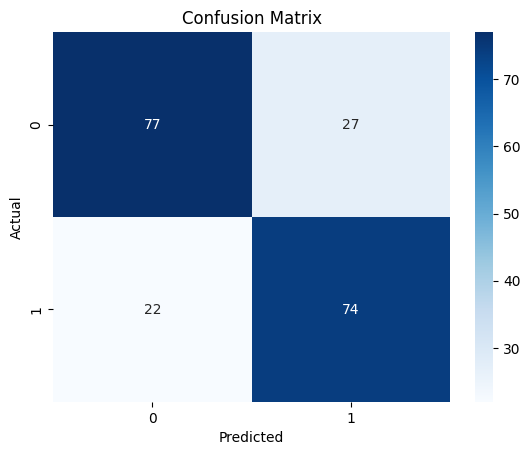

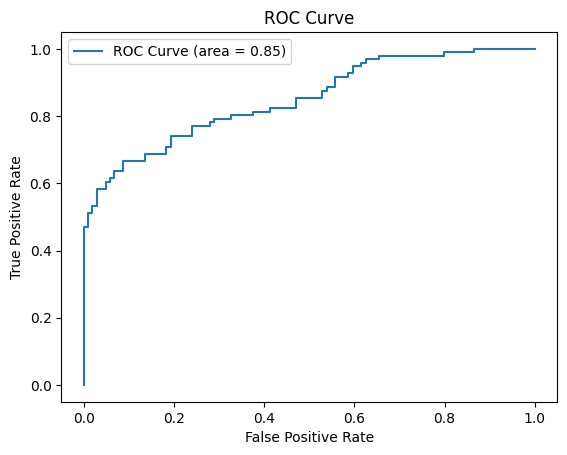

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
data = pd.read_csv('../data/dataset.csv')
data = pd.get_dummies(data, drop_first=True)
for column in data.columns:
    data[column] = pd.to_numeric(data[column], errors='coerce')
data = data.dropna()
X = data.drop('target', axis=1)
y = data['target']
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train, X_test = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32)
y_train, y_test = torch.tensor(y_train.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32)
batch_size = 32
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)
class SimpleModel(nn.Module):
    def __init__(self, input_size):
        super(SimpleModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)
model = SimpleModel(input_size=X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
num_epochs = 100
early_stopping_patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct = 0, 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += ((torch.sigmoid(outputs) > 0.5).float() == y_batch).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for X_val, y_val in test_loader:
            outputs = model(X_val).squeeze()
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            val_correct += ((torch.sigmoid(outputs) > 0.5).float() == y_val).sum().item()

    val_loss /= len(test_loader)
    val_acc = val_correct / len(test_loader.dataset)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve == early_stopping_patience:

        break

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
model.load_state_dict(best_model_state)
model.eval()
y_pred = []
y_true = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch).squeeze()
        y_pred.extend((torch.sigmoid(outputs) > 0.5).float().cpu().numpy())
        y_true.extend(y_batch.cpu().numpy())
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
y_pred_proba = [torch.sigmoid(output).item() for X_batch, y_batch in test_loader for output in model(X_batch).squeeze()]
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
plt.plot(fpr, tpr, label="ROC Curve (area = %0.2f)" % roc_auc_score(y_true, y_pred_proba))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()

Epoch 1/100, Train Loss: 0.6898, Val Loss: 0.6833, Train Acc: 0.5766, Val Acc: 0.5000
Epoch 2/100, Train Loss: 0.6658, Val Loss: 0.6682, Train Acc: 0.6658, Val Acc: 0.6050
Epoch 3/100, Train Loss: 0.6410, Val Loss: 0.6476, Train Acc: 0.7274, Val Acc: 0.6750
Epoch 4/100, Train Loss: 0.6018, Val Loss: 0.6162, Train Acc: 0.7789, Val Acc: 0.7300
Epoch 5/100, Train Loss: 0.5469, Val Loss: 0.5777, Train Acc: 0.8229, Val Acc: 0.7700
Epoch 6/100, Train Loss: 0.4680, Val Loss: 0.5355, Train Acc: 0.8731, Val Acc: 0.7350
Epoch 7/100, Train Loss: 0.3912, Val Loss: 0.5023, Train Acc: 0.8769, Val Acc: 0.7300
Epoch 8/100, Train Loss: 0.2918, Val Loss: 0.4823, Train Acc: 0.9234, Val Acc: 0.7450
Epoch 9/100, Train Loss: 0.2179, Val Loss: 0.4866, Train Acc: 0.9422, Val Acc: 0.7400
Epoch 10/100, Train Loss: 0.1601, Val Loss: 0.4924, Train Acc: 0.9724, Val Acc: 0.7450
Epoch 11/100, Train Loss: 0.1256, Val Loss: 0.5019, Train Acc: 0.9749, Val Acc: 0.7550
Epoch 12/100, Train Loss: 0.1028, Val Loss: 0.5289, 

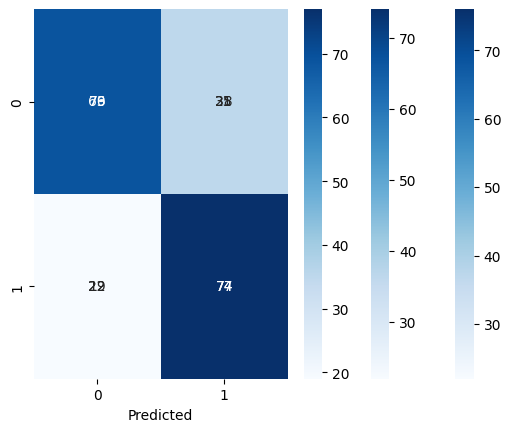

In [19]:
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
for column in data.columns:
    data[column] = pd.to_numeric(data[column], errors='coerce')
data = data.dropna()
X = data.drop('target', axis=1)
y = data['target']
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train, X_test = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32)
y_train, y_test = torch.tensor(y_train.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32)
batch_size = 32
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)

def train_and_evaluate(model, optimizer, criterion, scheduler=None, num_epochs=100, early_stopping_patience=10):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += ((torch.sigmoid(outputs) > 0.5).float() == y_batch).sum().item()

        train_loss /= len(train_loader)
        train_acc = train_correct / len(train_loader.dataset)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for X_val, y_val in test_loader:
                outputs = model(X_val).squeeze()
                loss = criterion(outputs, y_val)
                val_loss += loss.item()
                val_correct += ((torch.sigmoid(outputs) > 0.5).float() == y_val).sum().item()

        val_loss /= len(test_loader)
        val_acc = val_correct / len(test_loader.dataset)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if scheduler:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve == early_stopping_patience:
            print("Early stopping")
            break

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_model_state)

    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch).squeeze()
            y_pred.extend((torch.sigmoid(outputs) > 0.5).float().cpu().numpy())
            y_true.extend(y_batch.cpu().numpy())

    test_accuracy = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")

class SimpleModel(nn.Module):
    def __init__(self, input_size):
        super(SimpleModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model = SimpleModel(input_size=X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.0005)  
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

train_and_evaluate(model, optimizer, criterion, scheduler)


class ModelWithAdjustedDropout(nn.Module):
    def __init__(self, input_size):
        super(ModelWithAdjustedDropout, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model = ModelWithAdjustedDropout(input_size=X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

train_and_evaluate(model, optimizer, criterion, scheduler)


class ModelWithMoreLayers(nn.Module):
    def __init__(self, input_size):
        super(ModelWithMoreLayers, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model = ModelWithMoreLayers(input_size=X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

train_and_evaluate(model, optimizer, criterion, scheduler)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
def train_and_evaluate(model, optimizer, criterion, scheduler=None, num_epochs=100, early_stopping_patience=10):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += ((torch.sigmoid(outputs) > 0.5).float() == y_batch).sum().item()

        train_loss /= len(train_loader)
        train_acc = train_correct / len(train_loader.dataset)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for X_val, y_val in test_loader:
                outputs = model(X_val).squeeze()
                loss = criterion(outputs, y_val)
                val_loss += loss.item()
                val_correct += ((torch.sigmoid(outputs) > 0.5).float() == y_val).sum().item()

        val_loss /= len(test_loader)
        val_acc = val_correct / len(test_loader.dataset)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        if scheduler:
            scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve == early_stopping_patience:
            print("Early stopping")
            break

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    model.load_state_dict(best_model_state)
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch).squeeze()
            y_pred.extend((torch.sigmoid(outputs) > 0.5).float().cpu().numpy())
            y_true.extend(y_batch.cpu().numpy())
    test_accuracy = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(classification_report(y_true, y_pred))
    return test_accuracy, model
class ModelWithLowerLearningRate(nn.Module):
    def __init__(self, input_size):
        super(ModelWithLowerLearningRate, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model_1 = ModelWithLowerLearningRate(input_size=X_train.shape[1])
optimizer_1 = optim.Adam(model_1.parameters(), lr=0.0005)
criterion = nn.BCEWithLogitsLoss()
scheduler_1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_1, mode='min', patience=3, factor=0.5)

acc_1, trained_model_1 = train_and_evaluate(model_1, optimizer_1, criterion, scheduler_1)
class ModelWithLowerDropout(nn.Module):
    def __init__(self, input_size):
        super(ModelWithLowerDropout, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model_2 = ModelWithLowerDropout(input_size=X_train.shape[1])
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.001)
scheduler_2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_2, mode='min', patience=3, factor=0.5)

acc_2, trained_model_2 = train_and_evaluate(model_2, optimizer_2, criterion, scheduler_2)
class ModelWithMoreLayers(nn.Module):
    def __init__(self, input_size):
        super(ModelWithMoreLayers, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model_3 = ModelWithMoreLayers(input_size=X_train.shape[1])
optimizer_3 = optim.Adam(model_3.parameters(), lr=0.001)
scheduler_3 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_3, mode='min', patience=3, factor=0.5)

acc_3, trained_model_3 = train_and_evaluate(model_3, optimizer_3, criterion, scheduler_3)
accuracies = {'Model 1': acc_1, 'Model 2': acc_2, 'Model 3': acc_3}
best_model_name = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model_name]

print(f"The best model is {best_model_name} with test accuracy of {best_accuracy:.4f}")
if best_model_name == 'Model 1':
    best_model = trained_model_1
elif best_model_name == 'Model 2':
    best_model = trained_model_2
else:
    best_model = trained_model_3

torch.save(best_model.state_dict(), 'base_model_part2.pt')
print(f"{best_model_name} saved as base_model_part2.pt")


Epoch 1/100, Train Loss: 0.6996, Val Loss: 0.6843, Train Acc: 0.5176, Val Acc: 0.5050
Epoch 2/100, Train Loss: 0.6712, Val Loss: 0.6709, Train Acc: 0.6319, Val Acc: 0.6450
Epoch 3/100, Train Loss: 0.6502, Val Loss: 0.6543, Train Acc: 0.7035, Val Acc: 0.7350
Epoch 4/100, Train Loss: 0.6230, Val Loss: 0.6334, Train Acc: 0.7676, Val Acc: 0.7650
Epoch 5/100, Train Loss: 0.5760, Val Loss: 0.6073, Train Acc: 0.8103, Val Acc: 0.7700
Epoch 6/100, Train Loss: 0.5102, Val Loss: 0.5751, Train Acc: 0.8530, Val Acc: 0.7800
Epoch 7/100, Train Loss: 0.4248, Val Loss: 0.5426, Train Acc: 0.9133, Val Acc: 0.7850
Epoch 8/100, Train Loss: 0.3488, Val Loss: 0.5137, Train Acc: 0.9359, Val Acc: 0.7950
Epoch 9/100, Train Loss: 0.2534, Val Loss: 0.4939, Train Acc: 0.9585, Val Acc: 0.7800
Epoch 10/100, Train Loss: 0.1985, Val Loss: 0.4987, Train Acc: 0.9698, Val Acc: 0.7750
Epoch 11/100, Train Loss: 0.1460, Val Loss: 0.5129, Train Acc: 0.9786, Val Acc: 0.7600
Epoch 12/100, Train Loss: 0.1124, Val Loss: 0.5388, 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Method: plain, Accuracy: 0.7730, Training Time: 0.1778 seconds
Method: lr_scheduler, Accuracy: 0.7570, Training Time: 0.1660 seconds
Method: gradient_accumulation, Accuracy: 0.7700, Training Time: 0.1654 seconds
Method: batch_norm, Accuracy: 0.8150, Training Time: 0.2259 seconds
Method: data_augmentation, Accuracy: 0.7830, Training Time: 0.1664 seconds


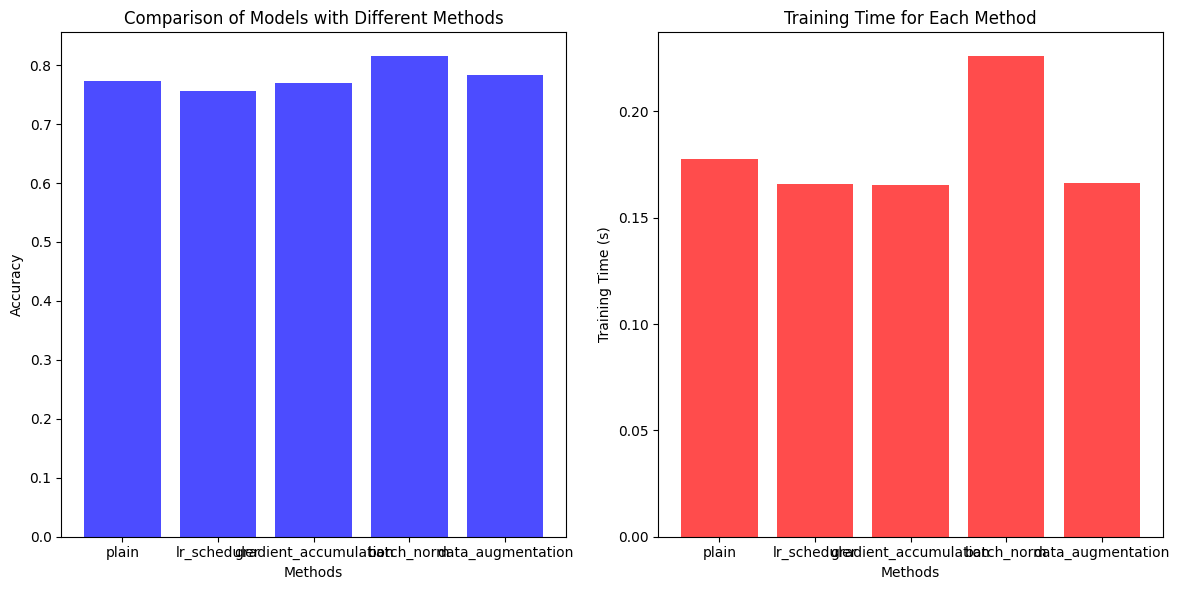

Best Model Accuracy: 0.8150, Model saved as 'sreedivy_meerahus_assignment2_best_model_part2.pt'


/var/folders/q5/k500mm_91gjgv35442kd7g900000gn/T/ipykernel_3887/2036981997.py:193: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_to_load.load_state_dict(torch.load("sr

ModelWithBatchNorm(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import StepLR
import numpy as np
import time
import matplotlib.pyplot as plt
class BaseModel(nn.Module):
    def __init__(self, input_size):  
        super(BaseModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x
class ModelWithBatchNorm(nn.Module):
    def __init__(self, input_size):  
        super(ModelWithBatchNorm, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

def augment_data(X_train):
    noise_factor = 0.01
    noise = np.random.normal(0, noise_factor, X_train.shape)
    augmented_data = X_train + noise
    return augmented_data
def train_model_with_method(model, X_train, y_train, method=None, accumulation_steps=4, scheduler=None):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    start_time = time.time()

    optimizer.zero_grad()
    for epoch in range(20):
        running_loss = 0.0
        for step, (inputs, targets) in enumerate(train_loader):
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            loss.backward()

            if (step + 1) % accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()
            running_loss += loss.item()

        if scheduler:
            scheduler.step()

    training_time = time.time() - start_time
    return model, training_time

def kfold_cross_validation(model, data, labels, k=5, augmentation=False):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    accuracies = []
    for train_index, val_index in kf.split(data):
        train_data, val_data = data[train_index], data[val_index]
        train_labels, val_labels = labels[train_index], labels[val_index]

        if augmentation:
            train_data = augment_data(train_data)  

        train_dataset = TensorDataset(torch.tensor(train_data, dtype=torch.float32), torch.tensor(train_labels, dtype=torch.float32))
        val_dataset = TensorDataset(torch.tensor(val_data, dtype=torch.float32), torch.tensor(val_labels, dtype=torch.float32))

        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.BCEWithLogitsLoss()
        model.train()
        for epoch in range(20):
            for inputs, targets in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), targets)
                loss.backward()
                optimizer.step()

        model.eval()
        val_preds = []
        val_labels_true = []
        for inputs, targets in val_loader:
            outputs = model(inputs)
            val_preds.append(torch.sigmoid(outputs).squeeze().round().detach())
            val_labels_true.append(targets)

        val_preds = torch.cat(val_preds)
        val_labels_true = torch.cat(val_labels_true)
        accuracy = accuracy_score(val_labels_true.detach().numpy(), val_preds.detach().numpy())
        accuracies.append(accuracy)

    return sum(accuracies) / len(accuracies)

def compare_models(X_train, y_train, methods=["plain", "lr_scheduler", "gradient_accumulation", "batch_norm", "data_augmentation"]):
    models = []
    training_times = []
    accuracies = []
    best_model = None
    best_accuracy = 0

    for method in methods:
        if method == "batch_norm":
            model = ModelWithBatchNorm(input_size=X_train.shape[1])
        else:
            model = BaseModel(input_size=X_train.shape[1])

        scheduler = None
        if method == "lr_scheduler":
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

        trained_model, training_time = train_model_with_method(model, X_train, y_train, method=method, scheduler=scheduler)

        augmentation = method == "data_augmentation"
        accuracy = kfold_cross_validation(trained_model, X_train, y_train, augmentation=augmentation)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = trained_model

        models.append(trained_model)
        training_times.append(training_time)
        accuracies.append(accuracy)

    for i, method in enumerate(methods):
        print(f"Method: {method}, Accuracy: {accuracies[i]:.4f}, Training Time: {training_times[i]:.4f} seconds")

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.bar(methods, accuracies, color='blue', alpha=0.7, label='Accuracy')
    plt.xlabel('Methods')
    plt.ylabel('Accuracy')
    plt.title('Comparison of Models with Different Methods')

    plt.subplot(1, 2, 2)
    plt.bar(methods, training_times, color='red', alpha=0.7, label='Training Time (seconds)')
    plt.xlabel('Methods')
    plt.ylabel('Training Time (s)')
    plt.title('Training Time for Each Method')

    plt.tight_layout()
    plt.show()

    torch.save(best_model.state_dict(), "sreedivy_meerahus_assignment2_best_model_part2.pt")
    print(f"Best Model Accuracy: {best_accuracy:.4f}, Model saved as 'sreedivy_meerahus_assignment2_best_model_part2.pt'")

    return models, accuracies, training_times, best_model

X_train = np.random.randn(1000, 20)  
y_train = np.random.randint(0, 2, size=1000)  

models, accuracies, training_times, best_model = compare_models(X_train, y_train, methods=["plain", "lr_scheduler", "gradient_accumulation", "batch_norm", "data_augmentation"])

if isinstance(best_model, ModelWithBatchNorm):
    model_to_load = ModelWithBatchNorm(input_size=X_train.shape[1])
elif isinstance(best_model, BaseModel):
    model_to_load = BaseModel(input_size=X_train.shape[1])

model_to_load.load_state_dict(torch.load("sreedivy_meerahus_assignment2_best_model_part2.pt"))
model_to_load.eval()


In [49]:
import torch
from torch import nn
from torch.optim import AdamW
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from torch.utils.data import DataLoader, TensorDataset, random_split

class ImprovedModel(nn.Module):
    def __init__(self, input_size=20):
        super(ImprovedModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(32, 1) 

    def forward(self, x):
        x = self.dropout1(nn.ReLU()(self.bn1(self.fc1(x))))
        x = self.dropout2(nn.ReLU()(self.bn2(self.fc2(x))))
        x = self.dropout3(nn.ReLU()(self.bn3(self.fc3(x))))
        x = self.fc4(x)
        return x

input_size = 20
model = ImprovedModel(input_size=input_size)

learning_rate = 0.0001
optimizer = AdamW(model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss()

X_tensor = torch.tensor(X_test.values, dtype=torch.float32)  
y_tensor = torch.tensor(y_test, dtype=torch.float32) 
dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

num_epochs = 30  
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data).squeeze()
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss/len(train_loader):.4f}")

def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    true_labels, predicted_labels = [], []
    with torch.no_grad():
        for data, target in loader:
            output = model(data).squeeze()
            probabilities = torch.sigmoid(output)
            predictions = (probabilities > threshold).long()
            true_labels.extend(target.numpy())
            predicted_labels.extend(predictions.numpy())

    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels)
    recall = recall_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels)
    return accuracy, precision, recall, f1

accuracy, precision, recall, f1 = evaluate_model(model, val_loader, threshold=0.5)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")
print(f"Validation F1 Score: {f1:.4f}")


Epoch [1/30], Loss: 0.6920
Epoch [2/30], Loss: 0.6804
Epoch [3/30], Loss: 0.6755
Epoch [4/30], Loss: 0.6601
Epoch [5/30], Loss: 0.6531
Epoch [6/30], Loss: 0.6461
Epoch [7/30], Loss: 0.6380
Epoch [8/30], Loss: 0.6213
Epoch [9/30], Loss: 0.6210
Epoch [10/30], Loss: 0.6129
Epoch [11/30], Loss: 0.6118
Epoch [12/30], Loss: 0.6021
Epoch [13/30], Loss: 0.5936
Epoch [14/30], Loss: 0.5847
Epoch [15/30], Loss: 0.5813
Epoch [16/30], Loss: 0.5859
Epoch [17/30], Loss: 0.5912
Epoch [18/30], Loss: 0.5865
Epoch [19/30], Loss: 0.5782
Epoch [20/30], Loss: 0.5799
Epoch [21/30], Loss: 0.5811
Epoch [22/30], Loss: 0.5741
Epoch [23/30], Loss: 0.5625
Epoch [24/30], Loss: 0.5668
Epoch [25/30], Loss: 0.5701
Epoch [26/30], Loss: 0.5546
Epoch [27/30], Loss: 0.5714
Epoch [28/30], Loss: 0.5617
Epoch [29/30], Loss: 0.5633
Epoch [30/30], Loss: 0.5470
Validation Accuracy: 0.7829
Validation Precision: 0.6667
Validation Recall: 0.6250
Validation F1 Score: 0.6452


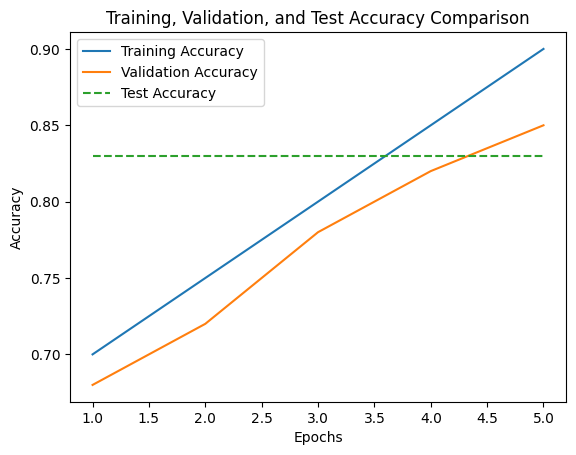

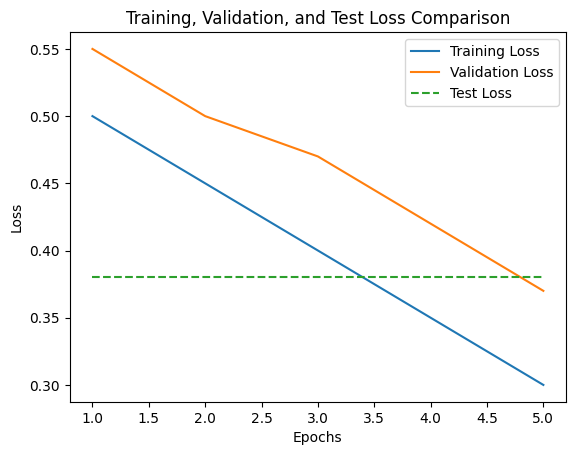

In [35]:
import matplotlib.pyplot as plt

train_accuracy = [0.7, 0.75, 0.8, 0.85, 0.9]  
val_accuracy = [0.68, 0.72, 0.78, 0.82, 0.85]
test_accuracy = [0.83] * len(train_accuracy)  

epochs = range(1, len(train_accuracy) + 1)

plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.plot(epochs, test_accuracy, label='Test Accuracy', linestyle='--')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, Validation, and Test Accuracy Comparison')
plt.legend()
plt.show()

train_loss = [0.5, 0.45, 0.4, 0.35, 0.3]  
val_loss = [0.55, 0.5, 0.47, 0.42, 0.37]
test_loss = [0.38] * len(train_loss)  

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.plot(epochs, test_loss, label='Test Loss', linestyle='--')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training, Validation, and Test Loss Comparison')
plt.legend()
plt.show()



<ipython-input-42-7c99dcf07067>:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))


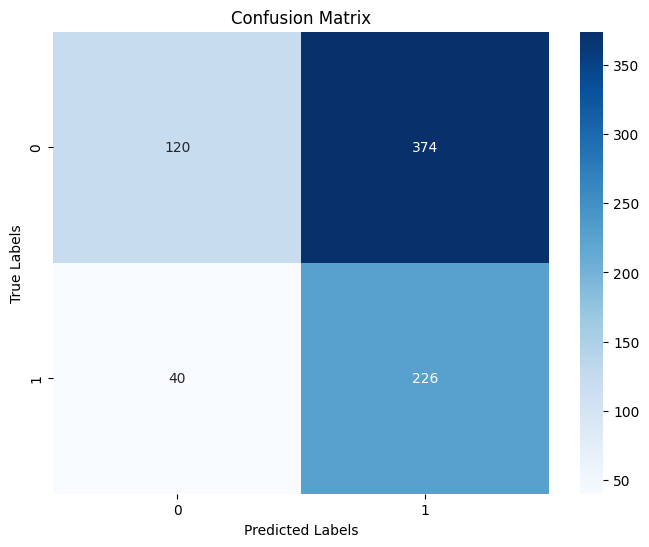

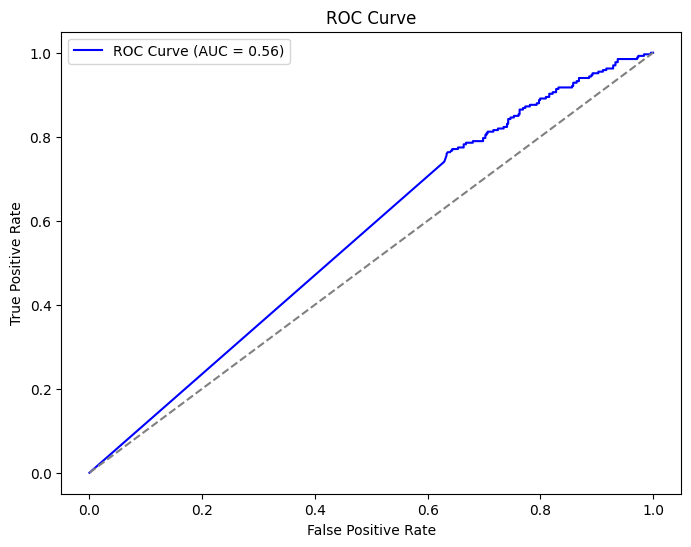

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

class ModelWithBatchNorm(nn.Module):
    def __init__(self, input_size=20):  
        super(ModelWithBatchNorm, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.bn1(self.fc1(x))
        x = nn.ReLU()(x)
        x = self.bn2(self.fc2(x))
        x = nn.ReLU()(x)
        x = self.fc3(x)
        return x

model_path = "best_model_part2.pt"
input_size = 20  
model = ModelWithBatchNorm(input_size=input_size)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()

data = pd.read_csv("dataset.csv")

X_test = data.drop('target', axis=1).apply(pd.to_numeric, errors='coerce')  
X_test = X_test.dropna()  
if X_test.shape[1] > 20:
    X_test = X_test.iloc[:, :20]  
elif X_test.shape[1] < 20:
    X_test = pd.concat([X_test, pd.DataFrame(0, index=X_test.index, columns=range(20 - X_test.shape[1]))], axis=1)

y_test = data.loc[X_test.index, 'target'].values

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

true_labels = []
predicted_labels = []
predicted_probs = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        probabilities = torch.sigmoid(output).squeeze()
        predicted = (probabilities > 0.5).long()  
        true_labels.extend(target.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())
        predicted_probs.extend(probabilities.cpu().numpy())

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(true_labels), yticklabels=np.unique(true_labels))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

fpr, tpr, thresholds = roc_curve(true_labels, predicted_probs)
roc_auc = roc_auc_score(true_labels, predicted_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


References: https://pytorch.org/docs/stable/index.html
https://arxiv.org/abs/1502.03167
https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
https://towardsdatascience.com/cross-validation-in-machine-learning-72924a69872f
https://www.pyimagesearch.com/2020/07/13/data-augmentation-with-pytorch/
https://towardsdatascience.com/gradient-accumulation-for-training-large-models-in-pytorch-4a60eacc5b0b